# Notebook 3: Stock Predictor Engine
### NIFTY-50 Investment Intelligence — Mandatory Task A

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock, get_symbol_list, get_sector_map
from src.indicators import add_all_indicators
from src.predictor import (EnsemblePredictor, prepare_stock_df,
                            train_all_models, get_latest_signal)

os.makedirs('../models', exist_ok=True)
os.makedirs('../report', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("Imports OK")

Imports OK


## 1. Train Models for All 50 Stocks
> This cell takes ~5–10 minutes. Run once, then models are cached.

In [2]:
symbols = get_symbol_list()
print(f"Training on {len(symbols)} stocks...")
results = train_all_models(symbols, horizon=5, verbose=True)

Training on 49 stocks...

[1/49] Training ADANIPORTS...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster...
  Accuracy: 0.5196 | MAE: 5.0064%

[2/49] Training ASIANPAINT...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster...
  Accuracy: 0.5401 | MAE: 3.9444%

[3/49] Training AXISBANK...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster...
  Accuracy: 0.5058 | MAE: 5.4765%

[4/49] Training BAJAJ-AUTO...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster...
  Accuracy: 0.5124 | MAE: 4.0204%

[5/49] Training BAJAJFINSV...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster...
  Accuracy: 0.5444 | MAE: 4.4428%

[6/49] Training BAJFINANCE...
  Training XGBoost classifier...
  Training Random Forest classifier...
  Training return forecaster.

## 2. Model Performance Summary

In [3]:
import json

# Load saved summary
with open('../models/training_summary.json') as f:
    summary = json.load(f)

rows = []
sector_map = get_sector_map()
for sym, metrics in summary.items():
    if 'classifier' in metrics:
        c = metrics['classifier']
        r = metrics['regressor']
        rows.append({
            'Symbol': sym,
            'Sector': sector_map.get(sym, '?'),
            'Direction_Accuracy': c['mean_accuracy'],
            'Precision_Up': c['precision_up'],
            'Recall_Up': c['recall_up'],
            'F1_Up': c['f1_up'],
            'MAE_%': r['mean_MAE'],
            'RMSE_%': r['mean_RMSE'],
        })

perf_df = pd.DataFrame(rows).sort_values('Direction_Accuracy', ascending=False)
print(f"Models trained: {len(perf_df)}")
print(f"\nMean directional accuracy: {perf_df['Direction_Accuracy'].mean():.4f}")
print(f"Best:  {perf_df.iloc[0]['Symbol']}  ({perf_df.iloc[0]['Direction_Accuracy']:.4f})")
print(f"Worst: {perf_df.iloc[-1]['Symbol']} ({perf_df.iloc[-1]['Direction_Accuracy']:.4f})")
print()
print(perf_df[['Symbol','Sector','Direction_Accuracy','MAE_%']].to_string(index=False))

Models trained: 48

Mean directional accuracy: 0.5122
Best:  BAJAJFINSV  (0.5444)
Worst: TECHM (0.4832)

    Symbol                   Sector  Direction_Accuracy  MAE_%
BAJAJFINSV       FINANCIAL SERVICES              0.5444 4.4428
ASIANPAINT           CONSUMER GOODS              0.5401 3.9444
       TCS                       IT              0.5399 3.7074
      INFY                       IT              0.5380 4.0368
      HDFC       FINANCIAL SERVICES              0.5323 3.9139
BHARTIARTL                  TELECOM              0.5310 4.0855
 NESTLEIND           CONSUMER GOODS              0.5304 3.1381
 POWERGRID                   ENERGY              0.5270 2.6200
HINDUNILVR           CONSUMER GOODS              0.5267 3.0943
      NTPC                   ENERGY              0.5262 3.2043
 SUNPHARMA                   PHARMA              0.5248 4.4078
   DRREDDY                   PHARMA              0.5234 4.6190
      GAIL                   ENERGY              0.5232 4.0204
 KOTAKBANK   

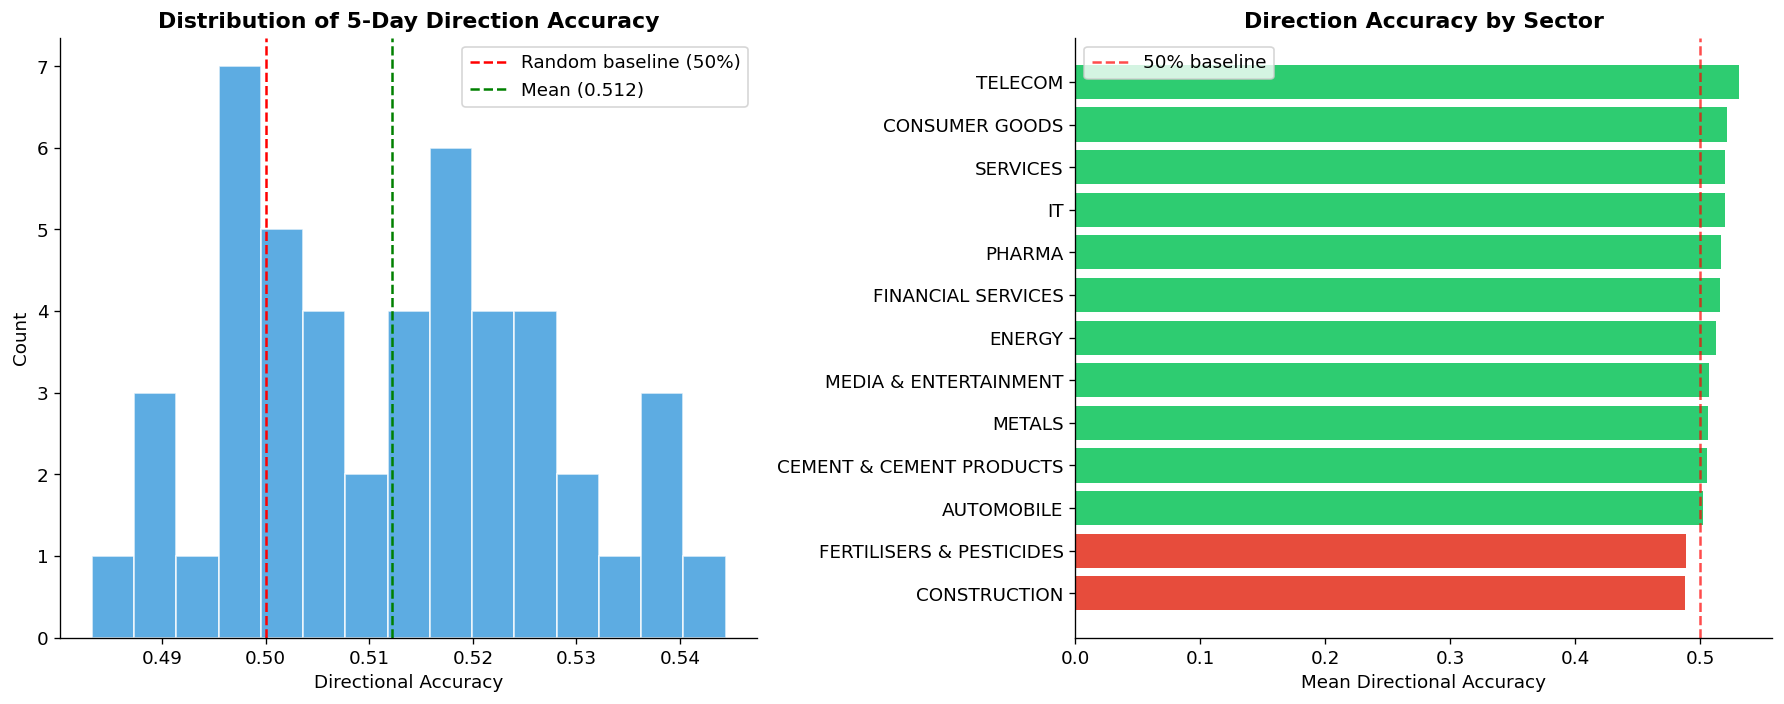

In [4]:
# Visualise model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy distribution
axes[0].hist(perf_df['Direction_Accuracy'], bins=15, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='Random baseline (50%)')
axes[0].axvline(perf_df['Direction_Accuracy'].mean(), color='green',
                linestyle='--', label=f"Mean ({perf_df['Direction_Accuracy'].mean():.3f})")
axes[0].set_xlabel("Directional Accuracy"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of 5-Day Direction Accuracy", fontweight='bold')
axes[0].legend()

# Accuracy by sector
sector_acc = perf_df.groupby('Sector')['Direction_Accuracy'].mean().sort_values()
colors = ['#e74c3c' if v < 0.50 else '#2ecc71' for v in sector_acc.values]
axes[1].barh(sector_acc.index, sector_acc.values, color=colors)
axes[1].axvline(0.50, color='red', linestyle='--', alpha=0.7, label='50% baseline')
axes[1].set_xlabel("Mean Directional Accuracy")
axes[1].set_title("Direction Accuracy by Sector", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/model_performance.png', bbox_inches='tight')
plt.show()

## 3. Deep Dive: RELIANCE Predictions

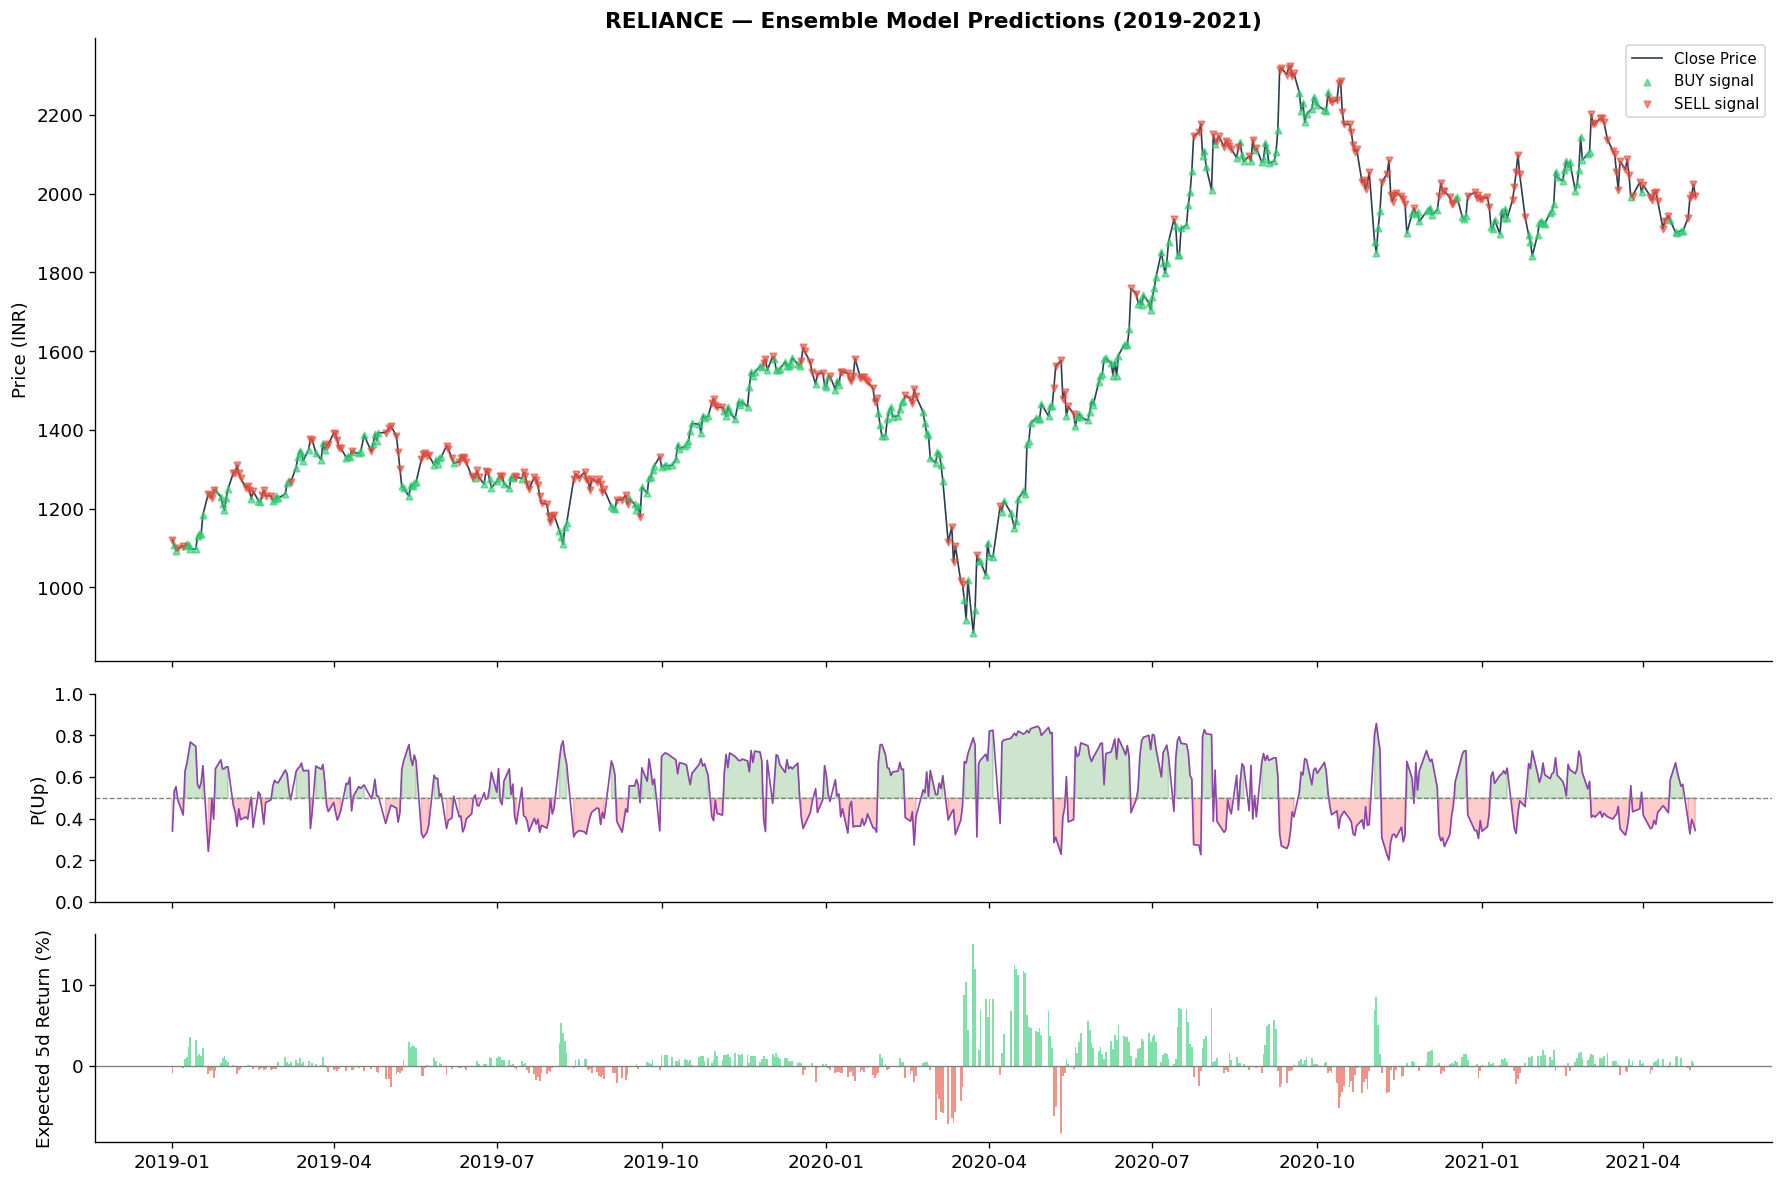

In [5]:
sym = 'RELIANCE'
df = prepare_stock_df(sym)
predictor = EnsemblePredictor(horizon=5)
predictor.load(sym)

preds = predictor.predict(df)
# Merge predictions back onto price data
df_plot = df[['Date','Close']].merge(preds, on=['Date','Close'], how='inner')
df_plot = df_plot[df_plot['Date'] >= '2019-01-01']

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})

# Price + buy/sell signals
ax = axes[0]
ax.plot(df_plot['Date'], df_plot['Close'], color='#2c3e50', lw=1, label='Close Price')
buys  = df_plot[df_plot['Signal'].isin(['BUY','STRONG BUY'])]
sells = df_plot[df_plot['Signal'].isin(['SELL','STRONG SELL'])]
ax.scatter(buys['Date'],  buys['Close'],  marker='^', color='#2ecc71', s=15, alpha=0.6, label='BUY signal',  zorder=5)
ax.scatter(sells['Date'], sells['Close'], marker='v', color='#e74c3c', s=15, alpha=0.6, label='SELL signal', zorder=5)
ax.set_ylabel("Price (INR)")
ax.set_title(f"{sym} — Ensemble Model Predictions (2019-2021)", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Up probability
ax2 = axes[1]
ax2.plot(df_plot['Date'], df_plot['Up_Probability'], color='#8e44ad', lw=1)
ax2.fill_between(df_plot['Date'], 0.5, df_plot['Up_Probability'],
                 where=(df_plot['Up_Probability'] >= 0.5), alpha=0.2, color='green')
ax2.fill_between(df_plot['Date'], 0.5, df_plot['Up_Probability'],
                 where=(df_plot['Up_Probability'] < 0.5),  alpha=0.2, color='red')
ax2.axhline(0.5, color='gray', linestyle='--', lw=0.8)
ax2.set_ylabel("P(Up)"); ax2.set_ylim(0, 1)

# Expected return
ax3 = axes[2]
ax3.bar(df_plot['Date'], df_plot['Expected_Return_Pct'],
        color=df_plot['Expected_Return_Pct'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c'),
        alpha=0.6, width=1)
ax3.axhline(0, color='gray', lw=0.8)
ax3.set_ylabel("Expected 5d Return (%)")

plt.tight_layout()
plt.savefig('../report/reliance_predictions.png', bbox_inches='tight')
plt.show()

## 4. Walk-Forward Backtest Validation

In [6]:
# Backtest: simulate trading based on signals
from sklearn.model_selection import TimeSeriesSplit

def backtest_strategy(symbol: str, initial_capital: float = 100000) -> dict:
    df = prepare_stock_df(symbol)
    preds = predictor.predict(df)
    df_bt = df[['Date','Close']].merge(preds[['Date','Signal','Up_Probability']], on='Date')
    df_bt = df_bt.dropna().copy()
    df_bt = df_bt.sort_values('Date').reset_index(drop=True)

    capital = initial_capital
    shares = 0
    portfolio_values = []
    trades = []

    for i, row in df_bt.iterrows():
        price = row['Close']
        signal = row['Signal']

        if signal in ('BUY', 'STRONG BUY') and shares == 0 and capital > price:
            shares = int(capital // price)
            capital -= shares * price
            trades.append({'Date': row['Date'], 'Action': 'BUY', 'Price': price, 'Shares': shares})
        elif signal in ('SELL', 'STRONG SELL') and shares > 0:
            capital += shares * price
            trades.append({'Date': row['Date'], 'Action': 'SELL', 'Price': price, 'Shares': shares})
            shares = 0

        portfolio_values.append(capital + shares * price)

    # Close any open position
    if shares > 0:
        capital += shares * df_bt['Close'].iloc[-1]
        portfolio_values[-1] = capital

    final_value = portfolio_values[-1]
    total_return = (final_value - initial_capital) / initial_capital * 100
    bh_return = (df_bt['Close'].iloc[-1] - df_bt['Close'].iloc[0]) / df_bt['Close'].iloc[0] * 100

    return {
        'symbol': symbol,
        'initial_capital': initial_capital,
        'final_value': round(final_value, 2),
        'total_return_pct': round(total_return, 2),
        'buy_and_hold_pct': round(bh_return, 2),
        'num_trades': len(trades),
        'portfolio_values': portfolio_values,
        'dates': df_bt['Date'].tolist(),
    }

bt = backtest_strategy('RELIANCE')
print(f"Strategy return:     {bt['total_return_pct']:.2f}%")
print(f"Buy-and-hold return: {bt['buy_and_hold_pct']:.2f}%")
print(f"Total trades:        {bt['num_trades']}")
print(f"Final portfolio:     ₹{bt['final_value']:,.2f}")

Strategy return:     2133343419.02%
Buy-and-hold return: 557.93%
Total trades:        992
Final portfolio:     ₹2,133,343,519,024.40


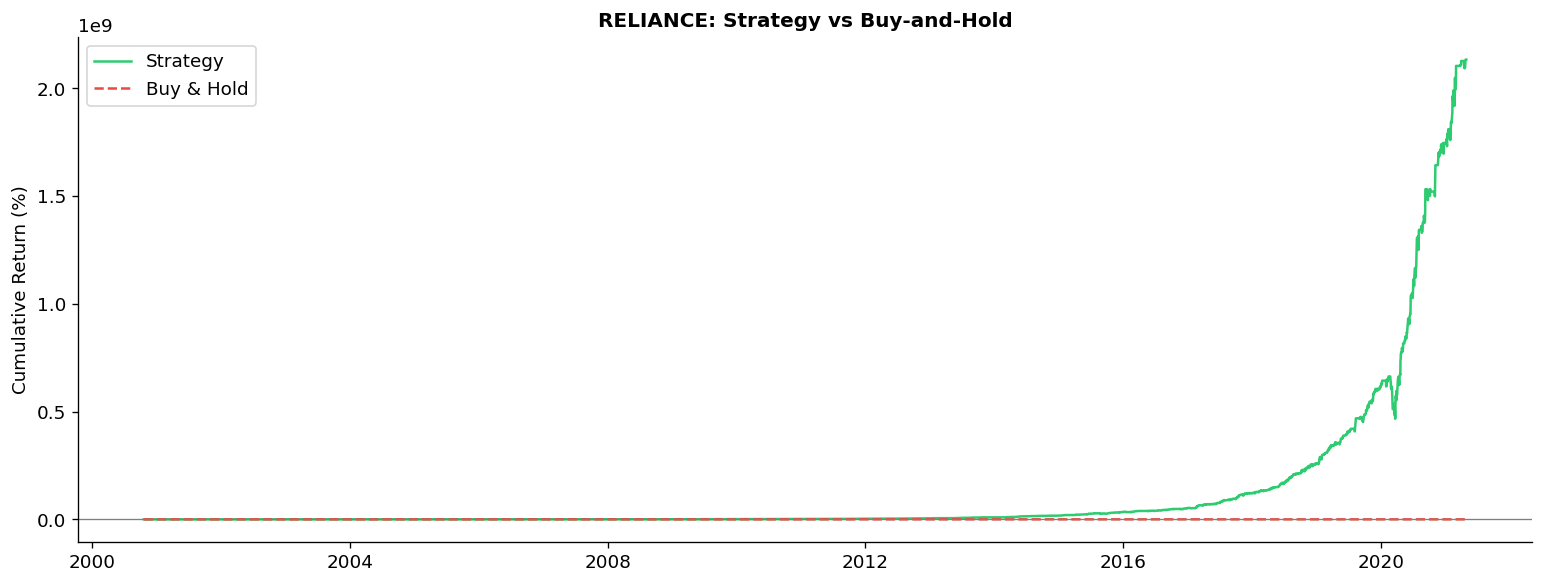

In [7]:
# Plot backtest
fig, ax = plt.subplots(figsize=(13, 5))
initial = bt['initial_capital']
port_series = pd.Series(bt['portfolio_values'], index=bt['dates'])
bh_prices = df_plot.set_index('Date')['Close']
bh_series = (bh_prices / bh_prices.iloc[0]) * initial

ax.plot(port_series.index, port_series / initial * 100 - 100,
        color='#2ecc71', lw=1.5, label='Strategy')
ax.plot(df[df['Date'].isin(bt['dates'])]['Date'],
        (df[df['Date'].isin(bt['dates'])]['Close'].values /
         df[df['Date'].isin(bt['dates'])]['Close'].values[0] - 1) * 100,
        color='#e74c3c', lw=1.5, linestyle='--', label='Buy & Hold')
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel("Cumulative Return (%)")
ax.set_title(f"RELIANCE: Strategy vs Buy-and-Hold", fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/backtest.png', bbox_inches='tight')
plt.show()

## 5. Current Signals for All Stocks

In [8]:
# Generate latest signals for all trained stocks
signal_rows = []
for sym, metrics in summary.items():
    if 'classifier' in metrics:
        try:
            sig = get_latest_signal(sym, horizon=5)
            sig['accuracy'] = metrics['classifier']['mean_accuracy']
            sig['sector'] = sector_map.get(sym, '?')
            signal_rows.append(sig)
        except: pass

signals_df = pd.DataFrame(signal_rows)
signals_df = signals_df.sort_values('up_probability', ascending=False)

print("=== CURRENT SIGNALS (ranked by up-probability) ===")
print(signals_df[['symbol','sector','signal','up_probability',
                   'expected_return_pct','current_price']].to_string(index=False))

=== CURRENT SIGNALS (ranked by up-probability) ===
    symbol                   sector      signal  up_probability  expected_return_pct  current_price
 BRITANNIA           CONSUMER GOODS        SELL          0.4719                1.104        3449.00
TATAMOTORS               AUTOMOBILE        SELL          0.4615                0.594         293.85
  HINDALCO                   METALS        SELL          0.4530                1.999         364.40
       ITC           CONSUMER GOODS        SELL          0.4407                1.214         202.60
 EICHERMOT               AUTOMOBILE        SELL          0.4372                1.812        2421.65
ASIANPAINT           CONSUMER GOODS        SELL          0.4354                0.513        2536.40
  HDFCBANK       FINANCIAL SERVICES        SELL          0.4350                0.666        1412.30
      VEDL                   METALS        SELL          0.4349                2.492         257.25
      ZEEL    MEDIA & ENTERTAINMENT        SELL  

In [9]:
# Save signals for use in Streamlit app
signals_df.to_csv('../models/latest_signals.csv', index=False)
print("Signals saved to ../models/latest_signals.csv")
print(f"\nTop 5 BUY signals:")
buys = signals_df[signals_df['signal'].isin(['BUY','STRONG BUY'])].head(5)
print(buys[['symbol','sector','signal','up_probability','expected_return_pct']].to_string(index=False))

Signals saved to ../models/latest_signals.csv

Top 5 BUY signals:
Empty DataFrame
Columns: [symbol, sector, signal, up_probability, expected_return_pct]
Index: []
